# 08 — IoT Feature Testi

**Soru:** WOFOST simülasyon feature'larını (RFTRA, TAGP, DVS) çıkarıp sadece
IoT sensör + Sentinel-2'den gelebilecek feature'larla model ne kadar iyi çalışır?

**Karşılaştırma:**
- **Full model** (notebook 04): WOFOST feature'ları dahil
- **IoT model**: Sadece sensörden/uydadan gelebilecek feature'lar

**IoT feature'ları:**
| Feature | Kaynak |
|---|---|
| mean_temp | IoT hava sıcaklığı |
| total_precip | Yağış ölçer / API |
| mean_humidity | IoT hava nemi |
| mean_soil_temp | IoT toprak sıcaklığı |
| mean_soil_moisture | IoT toprak nemi |
| max_lai | Sentinel-2 NDVI→LAI |
| season_days, lat, lon, elev, year, WAV, crop_te | Statik / bilinir |

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import lightgbm as lgb
import duckdb
import shap
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path

from src.data.loader import RAW_PATH

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

OUTPUTS = Path('../outputs')
FIGS    = OUTPUTS / 'figures'
MODELS  = OUTPUTS / 'models'
MODELS.mkdir(exist_ok=True)

CUTOFFS    = [30, 60, 90]
TEST_YEARS = [2023, 2024]
TARGET     = 'harvest_twso'

print('Hazır.')

Hazır.


## 1. Veri yükleme — IoT feature'ları dahil

In [2]:
def load_cutoff_iot(n_days: int) -> pd.DataFrame:
    """İlk n_days günlük veriyi aggregate et — IoT + Sentinel-2 feature'ları dahil."""
    return duckdb.query(f"""
        WITH season_start AS (
            SELECT
                latitude, longitude, elevation,
                crop_name, variety_name, year, wav_scenario, WAV,
                MIN(DATETIME::TIMESTAMP) AS start_ts,
                MAX(harvest_twso)        AS harvest_twso,
                MAX(sim_success)         AS sim_success
            FROM '{RAW_PATH}'
            GROUP BY latitude, longitude, elevation,
                     crop_name, variety_name, year, wav_scenario, WAV
        ),
        filtered AS (
            SELECT r.*
            FROM '{RAW_PATH}' r
            JOIN season_start s
              ON  r.latitude     = s.latitude
              AND r.longitude    = s.longitude
              AND r.crop_name    = s.crop_name
              AND r.year         = s.year
              AND r.wav_scenario = s.wav_scenario
            WHERE r.DATETIME::TIMESTAMP < s.start_ts + INTERVAL '{n_days} days'
        )
        SELECT
            f.latitude, f.longitude, f.elevation,
            f.crop_name, f.variety_name, f.year, f.wav_scenario, f.WAV,
            MAX(f.harvest_twso)        AS harvest_twso,
            MAX(f.sim_success)         AS sim_success,
            -- Hava (IoT)
            AVG(f.AIR_TEMP)            AS mean_temp,
            SUM(f.PRECIP)              AS total_precip,
            AVG(f.AIR_HUMIDITY)        AS mean_humidity,
            -- Toprak (IoT)
            AVG(f.SOIL_TEMP_0_7)       AS mean_soil_temp,
            AVG(f.SOIL_MOISTURE_0_7)   AS mean_soil_moisture,
            -- Sentinel-2 proxy
            MAX(f.LAI)                 AS max_lai,
            -- WOFOST (karşılaştırma için)
            AVG(f.RFTRA)               AS mean_rftra,
            MAX(f.TAGP)                AS max_tagp,
            MAX(f.DVS)                 AS max_dvs,
            COUNT(DISTINCT DATE_TRUNC('day', f.DATETIME::TIMESTAMP)) AS season_days
        FROM filtered f
        GROUP BY f.latitude, f.longitude, f.elevation,
                 f.crop_name, f.variety_name, f.year, f.wav_scenario, f.WAV
    """).df()

print('Fonksiyon hazır.')

Fonksiyon hazır.


In [3]:
datasets = {}
for n in CUTOFFS:
    print(f'Yükleniyor: ilk {n} gün...', end=' ')
    datasets[n] = load_cutoff_iot(n)
    print(f'{len(datasets[n]):,} satır')

datasets[30].head(3)

Yükleniyor: ilk 30 gün... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 satır
Yükleniyor: ilk 60 gün... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 satır
Yükleniyor: ilk 90 gün... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 satır


,latitude,longitude,elevation,crop_name,variety_name,year,wav_scenario,WAV,harvest_twso,sim_success,mean_temp,total_precip,mean_humidity,mean_soil_temp,mean_soil_moisture,max_lai,mean_rftra,max_tagp,max_dvs,season_days
0,40.0,38.0,1838.0,barley,Spring_barley_301,2014,normal,50,7144.511977,1,-4.646486,35.7,80.193424,-0.233917,0.331332,NaN,NaN,NaN,NaN,31
1,37.0,32.0,2544.0,cassava,Cassava_VanHeemst_1988,2014,normal,50,12.882444,1,-3.547847,199.4,83.174289,-1.874583,0.379647,NaN,NaN,NaN,NaN,31
2,37.0,33.5,1559.0,cassava,Cassava_VanHeemst_1988,2014,dry,10,82.323762,1,2.426542,30.2,72.967395,2.274806,0.266701,NaN,NaN,NaN,NaN,31


## 2. Feature setleri tanımla

In [4]:
# Notebook 04 ile aynı — karşılaştırma için baseline
FULL_FEATURES = [
    'mean_temp', 'total_precip', 'mean_humidity',
    'mean_rftra',
    'max_lai', 'max_tagp', 'max_dvs',
    'season_days',
    'latitude', 'longitude', 'elevation',
    'year', 'WAV', 'crop_te',
]

# Sadece IoT sensör + Sentinel-2'den gelebilecekler
IOT_FEATURES = [
    'mean_temp', 'total_precip', 'mean_humidity',
    'mean_soil_temp', 'mean_soil_moisture',   # IoT yeni feature'lar
    'max_lai',                                # Sentinel-2
    'season_days',
    'latitude', 'longitude', 'elevation',
    'year', 'WAV', 'crop_te',
]

print(f'Full model feature sayısı : {len(FULL_FEATURES)}')
print(f'IoT model feature sayısı  : {len(IOT_FEATURES)}')
print()
print('Çıkarılan WOFOST feature\'ları:', set(FULL_FEATURES) - set(IOT_FEATURES))
print('Eklenen IoT feature\'ları    :', set(IOT_FEATURES) - set(FULL_FEATURES))

Full model feature sayısı : 14
IoT model feature sayısı  : 13

Çıkarılan WOFOST feature'ları: {'max_dvs', 'max_tagp', 'mean_rftra'}
Eklenen IoT feature'ları    : {'mean_soil_moisture', 'mean_soil_temp'}


## 3. Model eğitimi — Full vs IoT

In [5]:
def prepare(df: pd.DataFrame, features: list):
    df = df[df['sim_success'] == 1].copy()
    train = df[~df['year'].isin(TEST_YEARS)].copy()
    test  = df[ df['year'].isin(TEST_YEARS)].copy()

    crop_mean = train.groupby('crop_name')[TARGET].mean().rename('crop_te')
    train = train.join(crop_mean, on='crop_name')
    test  = test.join(crop_mean, on='crop_name')
    test['crop_te'] = test['crop_te'].fillna(train[TARGET].mean())

    return train[features], train[TARGET], test[features], test[TARGET]


def train_model(X_tr, y_tr, X_te, y_te):
    model = lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.05,
        num_leaves=63, subsample=0.8,
        colsample_bytree=0.8, random_state=42, n_jobs=-1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    y_pred = model.predict(X_te)
    return model, y_pred, r2_score(y_te, y_pred), root_mean_squared_error(y_te, y_pred)


print('Fonksiyonlar hazır.')

Fonksiyonlar hazır.


In [6]:
results = {'full': {}, 'iot': {}}

for n in CUTOFFS:
    print(f'\n--- Day {n} ---')
    df = datasets[n]

    # Full model
    X_tr, y_tr, X_te, y_te = prepare(df, FULL_FEATURES)
    model_f, pred_f, r2_f, rmse_f = train_model(X_tr, y_tr, X_te, y_te)
    results['full'][n] = {'r2': r2_f, 'rmse': rmse_f, 'model': model_f,
                          'X_te': X_te, 'y_te': y_te, 'y_pred': pred_f}
    print(f'Full  | R²={r2_f:.4f}  RMSE={rmse_f:,.0f}')

    # IoT model
    X_tr, y_tr, X_te, y_te = prepare(df, IOT_FEATURES)
    model_i, pred_i, r2_i, rmse_i = train_model(X_tr, y_tr, X_te, y_te)
    results['iot'][n] = {'r2': r2_i, 'rmse': rmse_i, 'model': model_i,
                         'X_te': X_te, 'y_te': y_te, 'y_pred': pred_i}
    print(f'IoT   | R²={r2_i:.4f}  RMSE={rmse_i:,.0f}')
    print(f'Fark  | ΔR²={r2_f - r2_i:+.4f}  ΔRMSE={rmse_f - rmse_i:+,.0f}')


--- Day 30 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000232 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 889
[LightGBM] [Info] Number of data points in the train set: 34013, number of used features: 9
[LightGBM] [Info] Start training from score 2049.027386
Full  | R²=0.7170  RMSE=1,545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1398
[LightGBM] [Info] Number of data points in the train set: 34013, number of used features: 11
[LightGBM] [Info] Start training from score 2049.027386
IoT   | R²=0.7231  RMSE=1,529
Fark  | ΔR²=-0.0060  ΔRMSE=+17

--- Day 60 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the

## 4. Karşılaştırma grafiği

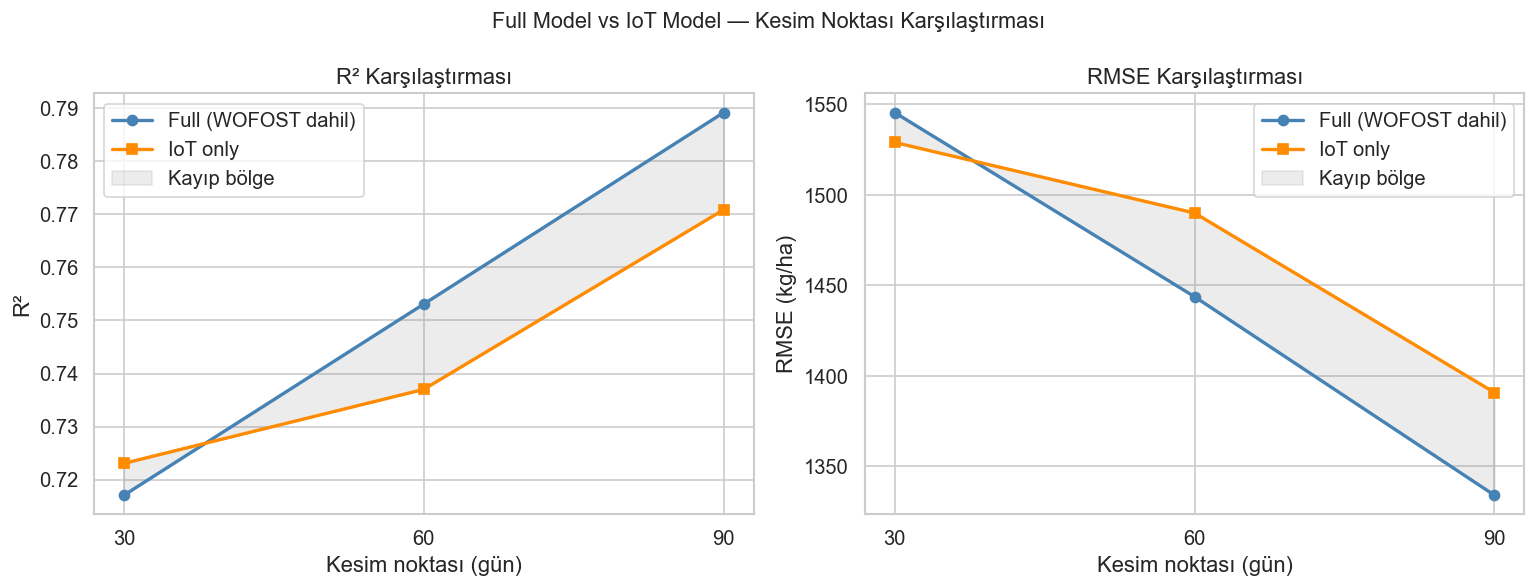

In [7]:
days   = CUTOFFS
r2_f   = [results['full'][n]['r2']   for n in days]
r2_i   = [results['iot'][n]['r2']    for n in days]
rmse_f = [results['full'][n]['rmse'] for n in days]
rmse_i = [results['iot'][n]['rmse']  for n in days]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# R²
axes[0].plot(days, r2_f, marker='o', color='steelblue',  lw=2, label='Full (WOFOST dahil)')
axes[0].plot(days, r2_i, marker='s', color='darkorange', lw=2, label='IoT only')
axes[0].fill_between(days, r2_i, r2_f, alpha=0.15, color='gray', label='Kayıp bölge')
axes[0].set_xlabel('Kesim noktası (gün)')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Karşılaştırması')
axes[0].legend()
axes[0].set_xticks(days)

# RMSE
axes[1].plot(days, rmse_f, marker='o', color='steelblue',  lw=2, label='Full (WOFOST dahil)')
axes[1].plot(days, rmse_i, marker='s', color='darkorange', lw=2, label='IoT only')
axes[1].fill_between(days, rmse_f, rmse_i, alpha=0.15, color='gray', label='Kayıp bölge')
axes[1].set_xlabel('Kesim noktası (gün)')
axes[1].set_ylabel('RMSE (kg/ha)')
axes[1].set_title('RMSE Karşılaştırması')
axes[1].legend()
axes[1].set_xticks(days)

plt.suptitle('Full Model vs IoT Model — Kesim Noktası Karşılaştırması', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'iot_vs_full_comparison.png', bbox_inches='tight')
plt.show()

## 5. Feature importance — IoT modeli

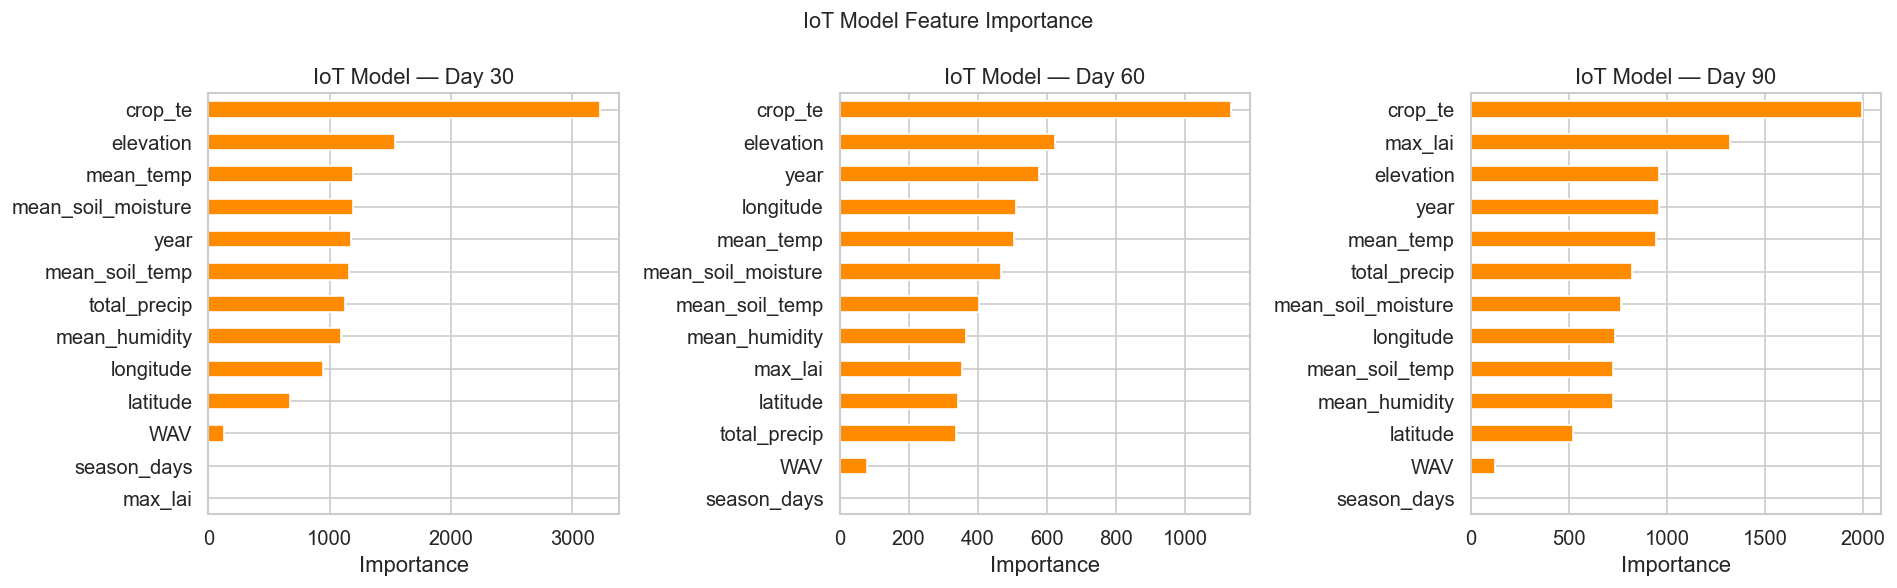

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, n in zip(axes, CUTOFFS):
    model = results['iot'][n]['model']
    imp = pd.Series(model.feature_importances_, index=IOT_FEATURES).sort_values()
    imp.plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title(f'IoT Model — Day {n}')
    ax.set_xlabel('Importance')

plt.suptitle('IoT Model Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'iot_feature_importance.png', bbox_inches='tight')
plt.show()

## 6. SHAP analizi — IoT Day 60 modeli

Hangi sensör verisi verimi en çok etkiliyor?

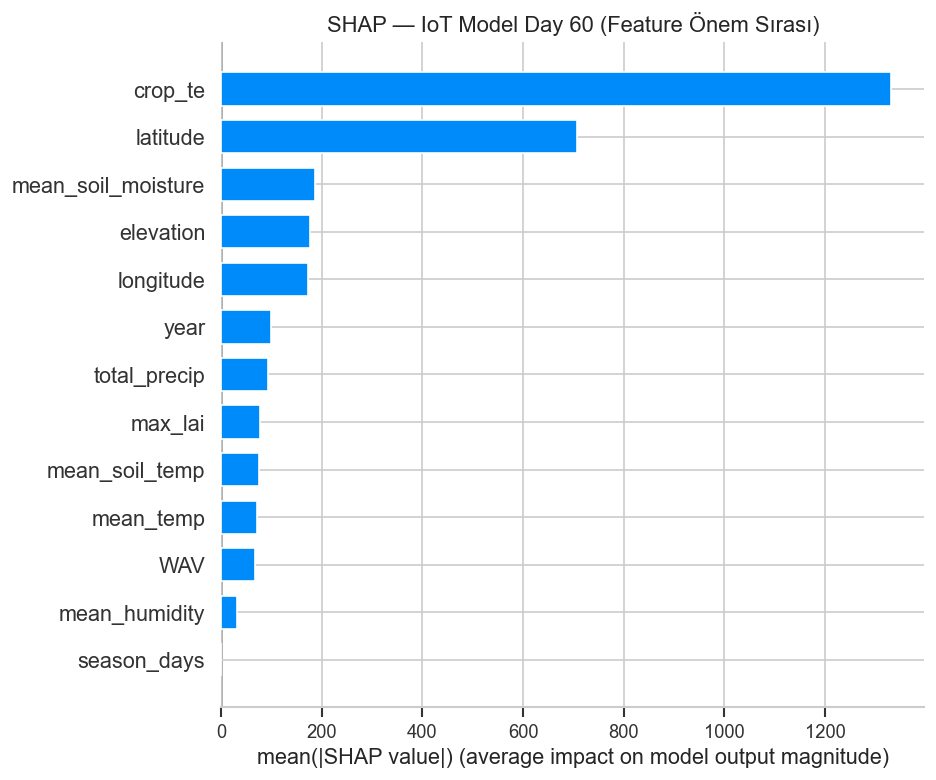

In [9]:
model_60 = results['iot'][60]['model']
X_te_60  = results['iot'][60]['X_te']

explainer = shap.TreeExplainer(model_60)
shap_values = explainer.shap_values(X_te_60)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_te_60, plot_type='bar', show=False)
plt.title('SHAP — IoT Model Day 60 (Feature Önem Sırası)')
plt.tight_layout()
plt.savefig(FIGS / 'iot_shap_importance.png', bbox_inches='tight')
plt.show()

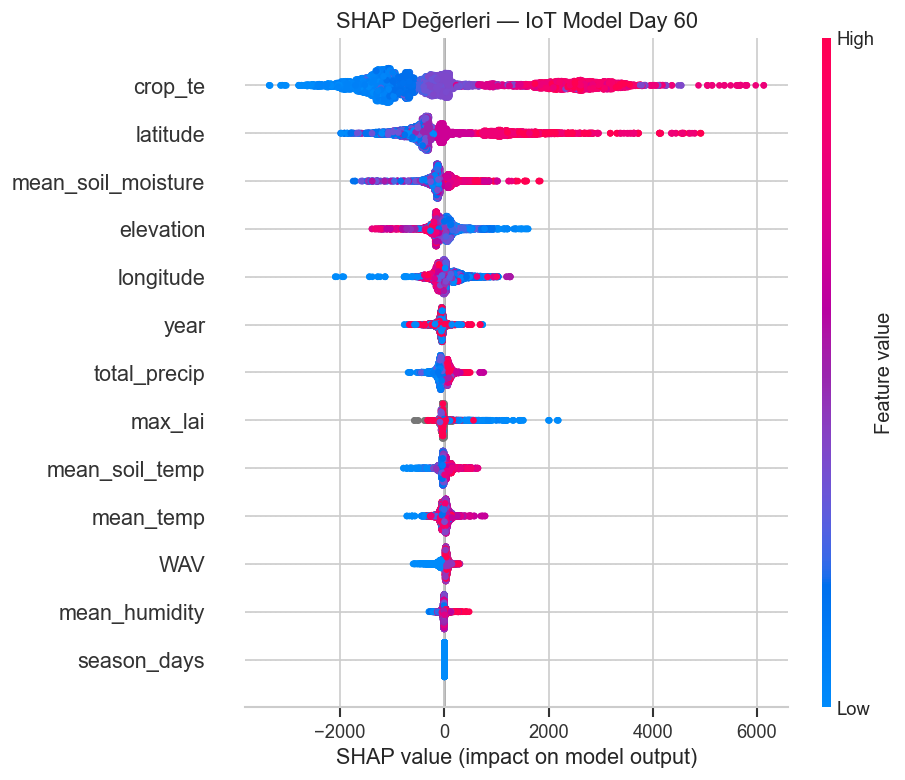

In [10]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_te_60, show=False)
plt.title('SHAP Değerleri — IoT Model Day 60')
plt.tight_layout()
plt.savefig(FIGS / 'iot_shap_beeswarm.png', bbox_inches='tight')
plt.show()

## 7. Tahmin vs Gerçek — IoT modeli

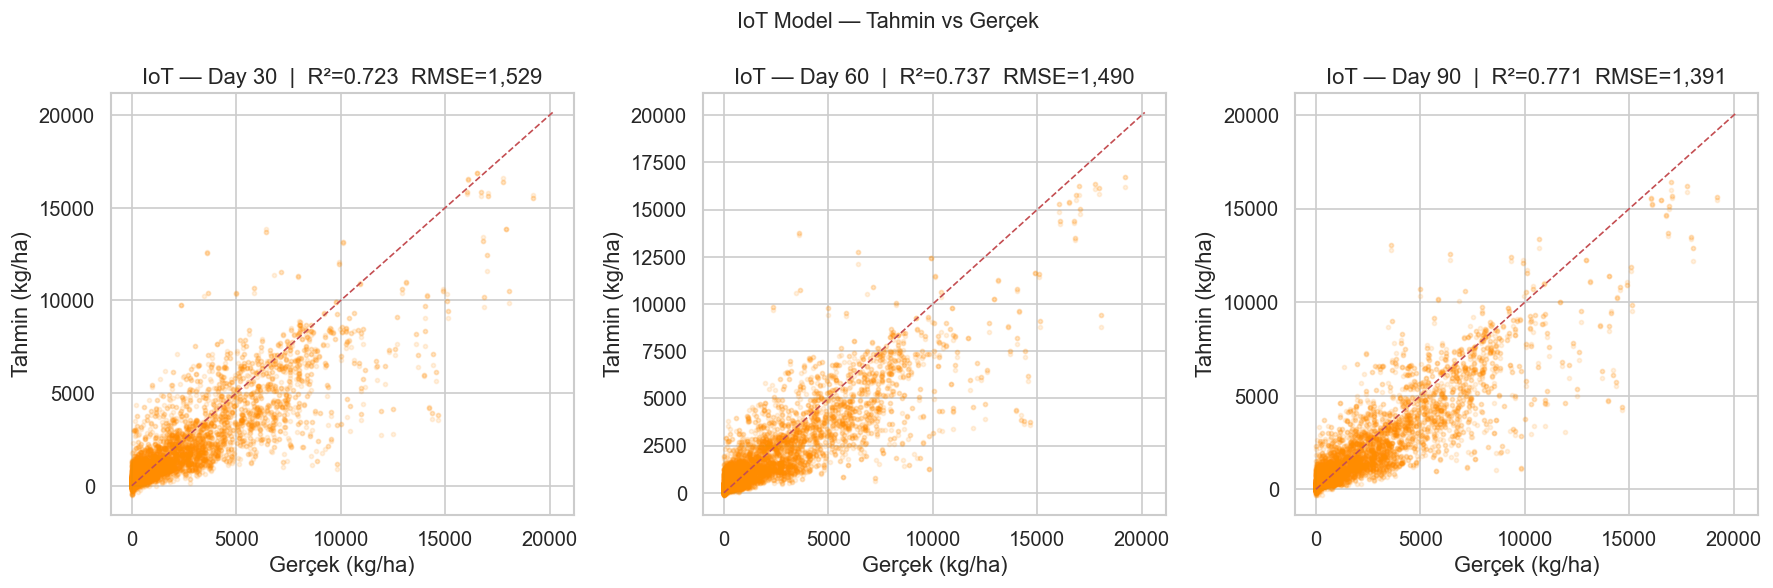

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n in zip(axes, CUTOFFS):
    y_te   = results['iot'][n]['y_te']
    y_pred = results['iot'][n]['y_pred']
    r2     = results['iot'][n]['r2']
    rmse   = results['iot'][n]['rmse']

    ax.scatter(y_te, y_pred, alpha=0.12, s=6, color='darkorange')
    lim = max(y_te.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1)
    ax.set_title(f'IoT — Day {n}  |  R²={r2:.3f}  RMSE={rmse:,.0f}')
    ax.set_xlabel('Gerçek (kg/ha)')
    ax.set_ylabel('Tahmin (kg/ha)')

plt.suptitle('IoT Model — Tahmin vs Gerçek', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'iot_pred_vs_actual.png', bbox_inches='tight')
plt.show()

## 8. Özet tablo ve karar

In [12]:
import json

summary = {}
print(f"{'Gün':<6} {'Full R²':>10} {'IoT R²':>10} {'ΔR²':>8} {'Full RMSE':>12} {'IoT RMSE':>12} {'ΔRMSE':>10}")
print('-' * 72)

for n in CUTOFFS:
    r2_f   = results['full'][n]['r2']
    r2_i   = results['iot'][n]['r2']
    rmse_f = results['full'][n]['rmse']
    rmse_i = results['iot'][n]['rmse']
    print(f"{n:<6} {r2_f:>10.4f} {r2_i:>10.4f} {r2_f-r2_i:>+8.4f} {rmse_f:>12,.0f} {rmse_i:>12,.0f} {rmse_f-rmse_i:>+10,.0f}")
    summary[str(n)] = {
        'full_r2': round(r2_f, 4), 'iot_r2': round(r2_i, 4),
        'full_rmse': round(rmse_f, 1), 'iot_rmse': round(rmse_i, 1),
    }

with open(OUTPUTS / 'iot_feature_test_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\nMetrikler kaydedildi.')

Gün       Full R²     IoT R²      ΔR²    Full RMSE     IoT RMSE      ΔRMSE
------------------------------------------------------------------------
30         0.7170     0.7231  -0.0060        1,545        1,529        +17
60         0.7531     0.7370  +0.0161        1,444        1,490        -46
90         0.7892     0.7709  +0.0183        1,334        1,391        -57

Metrikler kaydedildi.


In [13]:
# IoT modellerini kaydet — production sistemde kullanılacak
import joblib

for n in CUTOFFS:
    path = MODELS / f'iot_lgbm_day{n}.joblib'
    joblib.dump(results['iot'][n]['model'], path)
    print(f'Kaydedildi: {path}')

print('\nTüm IoT modelleri kaydedildi.')

Kaydedildi: ../outputs/models/iot_lgbm_day30.joblib
Kaydedildi: ../outputs/models/iot_lgbm_day60.joblib
Kaydedildi: ../outputs/models/iot_lgbm_day90.joblib

Tüm IoT modelleri kaydedildi.


## 9. Karar: Production'a hazır mı?

**Kabul kriteri:** IoT model R² ≥ 0.65 olursa sistem production'a hazır sayılır.

- R² ≥ 0.70 → Doğrudan kullanılabilir
- R² 0.65–0.70 → Kabul edilebilir, LSTM ile iyileştirilebilir
- R² < 0.65 → Ek feature engineering gerekli

In [14]:
print('=== KARAR ===')
for n in CUTOFFS:
    r2 = results['iot'][n]['r2']
    if r2 >= 0.70:
        status = '✅ Doğrudan kullanılabilir'
    elif r2 >= 0.65:
        status = '⚠️  Kabul edilebilir — LSTM ile iyileştir'
    else:
        status = '❌ Ek feature engineering gerekli'
    print(f'Day {n:3d} | R²={r2:.4f} | {status}')

=== KARAR ===
Day  30 | R²=0.7231 | ✅ Doğrudan kullanılabilir
Day  60 | R²=0.7370 | ✅ Doğrudan kullanılabilir
Day  90 | R²=0.7709 | ✅ Doğrudan kullanılabilir
